# Deflated Sharpe Ratio Validation

**Docker image**: `ml4t`

**Book Reference**: Chapter 16, §16.7 - strategy-level overfitting control.

This notebook demonstrates comprehensive **backtest validation using the Deflated Sharpe Ratio (DSR)** from `ml4t-diagnostic`.

## Key Concepts

1. **Selection Bias Correction**: Adjust for multiple strategy testing
2. **Non-Normality Adjustments**: Account for skewness and kurtosis
3. **Probabilistic Interpretation**: One-sided evidence against a selection benchmark
4. **Practical Thresholds**: When is a Sharpe ratio statistically significant?

## The Multiple Testing Problem

When we test N strategies and pick the best:
- **Expected max Sharpe under null**: E[max(SR₁,...,SRₙ)] ≈ √(2 log N) × σ_SR
- **A selected Sharpe can be misleading**: Its null benchmark rises with the trial count
- **DSR corrects**: Tests the observed Sharpe against a trial-adjusted benchmark

## References

- Bailey, D.H. & López de Prado, M. (2014). "The Deflated Sharpe Ratio"
- López de Prado, M. (2018). "Advances in Financial Machine Learning", Ch. 14

In [1]:
"""Validate Sharpe-ratio corrections for selection bias and non-normal returns."""

import os
from itertools import combinations

import numpy as np
import plotly.graph_objects as go
import polars as pl

# ml4t-diagnostic
from ml4t.diagnostic.evaluation.stats import (
    rademacher_complexity,
    ras_sharpe_adjustment,
)
from plotly.subplots import make_subplots
from scipy import stats

import utils  # noqa: F401
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, ml4t_diverging

In [2]:
# Production defaults - Papermill injects overrides after this cell
N_SIMULATIONS = 10000
SEED = 42

In [3]:
set_global_seeds(SEED)

In [4]:
EULER_MASCHERONI = 0.5772156649
PLOTLY_RENDERER = os.environ.get("PLOTLY_RENDERER", "").lower()


def show_plot(fig: go.Figure) -> None:
    """Display figure unless running in JSON-only renderer mode."""
    if PLOTLY_RENDERER != "json":
        fig.show()

### Deflated Sharpe Ratio Helper

A self-contained DSR implementation for demonstrating the math
step by step. The production helper in `ml4t-diagnostic` is compared below.

In [5]:
def _expected_max_sharpe(variance_trials: float, n_trials: int) -> float:
    """Expected maximum trial Sharpe in its native sampling frequency."""
    if n_trials <= 1 or variance_trials <= 0:
        return 0.0
    z1 = stats.norm.ppf(1.0 - (1.0 / n_trials))
    z2 = stats.norm.ppf(1.0 - (np.exp(-1.0) / n_trials))
    weight = (1.0 - EULER_MASCHERONI) * z1 + EULER_MASCHERONI * z2
    return float(np.sqrt(variance_trials) * weight)

Format the DSR components on the annualized reporting scale.

In [6]:
def _format_dsr_result(
    probability: float,
    z_score: float,
    expected_max: float,
    annualizer: float,
    observed_sharpe: float,
    confidence_level: float,
) -> dict[str, float | bool]:
    """Expose DSR components on the annualized scale used by the notebook."""
    expected_max_annual = expected_max * annualizer
    return {
        "dsr": probability,
        "z_score": z_score,
        "p_value": 1.0 - probability,
        "expected_max_sharpe": expected_max_annual,
        "adjusted_sharpe": observed_sharpe - expected_max_annual,
        "is_significant": probability >= confidence_level,
    }

Compute the deflated Sharpe ratio from annualized inputs and native observations.

In [7]:
def deflated_sharpe_ratio(
    observed_sharpe: float,
    skewness: float = 0.0,
    kurtosis: float = 3.0,
    n_samples: int = 252,
    n_trials: int = 1,
    variance_trials: float = 0.0,
    confidence_level: float = 0.95,
    return_format: str = "probability",
    return_components: bool = False,
    periods_per_year: int = 252,
) -> float | dict[str, float | bool]:
    """Compute DSR from annualized Sharpe statistics and native observations."""
    annualizer = np.sqrt(periods_per_year)
    observed_native = observed_sharpe / annualizer
    variance_native = max(variance_trials, 0.0) / periods_per_year
    expected_max = _expected_max_sharpe(variance_native, n_trials)
    variance = 1.0 - skewness * observed_native + ((kurtosis - 1.0) / 4.0) * observed_native**2
    denominator = np.sqrt(max(variance, 1e-12))
    z_score = (observed_native - expected_max) * np.sqrt(max(n_samples - 1, 1)) / denominator
    probability = float(stats.norm.cdf(z_score))
    components = _format_dsr_result(
        probability, float(z_score), expected_max, annualizer, observed_sharpe, confidence_level
    )
    if return_components:
        return components
    if return_format == "probability":
        return probability
    if return_format == "zscore":
        return float(z_score)
    if return_format in {"adjusted_sharpe", "adjusted"}:
        return float(components["adjusted_sharpe"])
    if return_format == "p_value":
        return float(components["p_value"])
    raise ValueError(f"Unknown return_format: {return_format}")

### Library Comparison

The implementation above shows the math explicitly. In practice (and in the
case study notebooks), we use `ml4t-diagnostic` directly. The library is not
a drop-in match for the bare formula above. It rescales the cross-trial Sharpe
variance with its finite-sample multiple-trial convention and evaluates the
non-normal variance at the adjusted benchmark. It also supports autocorrelation
and returns a minimum-track-record (MinTRL) diagnostic. The local helper uses
the observed Sharpe in the non-normal variance term to expose the paper's
equation directly.

In [8]:
from ml4t.diagnostic.evaluation.stats import (
    deflated_sharpe_ratio_from_statistics,
)

# Fixed-input comparison of the two documented conventions.
_test_sr, _test_skew, _test_kurt, _test_n = 1.5, -0.3, 4.0, 252
_test_trials, _test_var = 50, 0.5

_local_prob = deflated_sharpe_ratio(
    observed_sharpe=_test_sr,
    skewness=_test_skew,
    kurtosis=_test_kurt,
    n_samples=_test_n,
    n_trials=_test_trials,
    variance_trials=_test_var,
    return_format="probability",
)

_lib_result = deflated_sharpe_ratio_from_statistics(
    observed_sharpe=_test_sr / np.sqrt(252),  # library works at native frequency
    n_samples=_test_n,
    n_trials=_test_trials,
    variance_trials=_test_var / 252,
    skewness=_test_skew,
    excess_kurtosis=_test_kurt - 3.0,
)

print("=== Library Comparison ===")
print(f"Local DSR probability:   {_local_prob:.4f}")
print(f"Library DSR probability: {_lib_result.probability:.4f}")
print("\nThe library also supports autocorrelation and returns MinTRL:")
print(f"  Min track record:      {_lib_result.min_trl_years:.1f} years")
print(f"  Adequate sample:       {_lib_result.has_adequate_sample}")
print("\nIn practice, use the library:")
print("  from ml4t.diagnostic.evaluation.stats import deflated_sharpe_ratio")
print("  result = deflated_sharpe_ratio(returns)  # pass raw returns directly")

=== Library Comparison ===
Local DSR probability:   0.4572
Library DSR probability: 0.4082

The library also supports autocorrelation and returns MinTRL:
  Min track record:      1.2 years
  Adequate sample:       False

In practice, use the library:
  from ml4t.diagnostic.evaluation.stats import deflated_sharpe_ratio
  result = deflated_sharpe_ratio(returns)  # pass raw returns directly


### Probabilistic Sharpe Ratio Helper

Local implementation used by validation examples in this notebook.

In [9]:
# Implement probabilistic_sharpe_ratio locally (not in ml4t-diagnostic)
def probabilistic_sharpe_ratio(
    observed_sr: float,
    benchmark_sr: float = 0.0,
    n_observations: int = 252,
    skewness: float = 0.0,
    kurtosis: float = 3.0,
    periods_per_year: int = 252,
) -> float:
    """Compute PSR from annualized Sharpes and native-frequency observations."""
    annualizer = np.sqrt(periods_per_year)
    observed_native = observed_sr / annualizer
    benchmark_native = benchmark_sr / annualizer
    variance = 1.0 - skewness * observed_native + ((kurtosis - 1.0) / 4.0) * observed_native**2
    se_sr = np.sqrt(max(variance, 1e-12) / max(n_observations - 1, 1))
    z = (observed_native - benchmark_native) / se_sr
    return float(stats.norm.cdf(z))


np.random.seed(42)

## 1. Understanding the Deflated Sharpe Ratio

The DSR adjusts an observed Sharpe ratio for:
1. **Number of trials (K)**: More strategies tested = higher expected max
2. **Non-normality**: Skewed/fat-tailed returns inflate Sharpe
3. **Variance of trials**: High variance among tested strategies

$$DSR = \Phi\!\left(\frac{(\widehat{SR}-SR_0^*)\sqrt{T-1}}
{\sqrt{1-\gamma_3\widehat{SR}+\frac{\gamma_4-1}{4}\widehat{SR}^{\,2}}}\right)$$

The Sharpe quantities in this expression use the return series' native
frequency. The helper accepts annualized Sharpes and converts them internally.

In [10]:
def demonstrate_selection_bias(n_strategies: int = 100, n_periods: int = 252) -> dict:
    """
    Demonstrate selection bias from multiple testing.

    Under the null (all strategies have true SR=0), the best observed
    Sharpe will be significantly positive due to luck.
    """
    # Simulate n_strategies, all with true Sharpe = 0
    all_sharpes = []

    for _ in range(n_strategies):
        # Generate random returns (no edge)
        returns = np.random.normal(0, 0.01, n_periods)
        sharpe = np.mean(returns) / np.std(returns, ddof=1) * np.sqrt(252)
        all_sharpes.append(sharpe)

    all_sharpes = np.array(all_sharpes)

    return {
        "mean_sharpe": np.mean(all_sharpes),
        "max_sharpe": np.max(all_sharpes),
        "min_sharpe": np.min(all_sharpes),
        "std_sharpe": np.std(all_sharpes, ddof=1),
        "expected_max_theory": np.sqrt(252 / n_periods) * np.sqrt(2 * np.log(n_strategies)),
        "all_sharpes": all_sharpes,
    }


# Run simulation
results = demonstrate_selection_bias(n_strategies=100)

print("=" * 60)
print("SELECTION BIAS DEMONSTRATION")
print("Testing 100 strategies with TRUE Sharpe = 0")
print("=" * 60)
print(f"\nMean observed Sharpe: {results['mean_sharpe']:.3f}")
print(f"Best observed Sharpe: {results['max_sharpe']:.3f}")
print(f"Worst observed Sharpe: {results['min_sharpe']:.3f}")
print(f"\nExpected max (theory): {results['expected_max_theory']:.3f}")
print("\n>> The 'best' strategy looks great but has NO skill!")

SELECTION BIAS DEMONSTRATION
Testing 100 strategies with TRUE Sharpe = 0

Mean observed Sharpe: -0.002
Best observed Sharpe: 2.532
Worst observed Sharpe: -3.288

Expected max (theory): 3.035

>> The 'best' strategy looks great but has NO skill!


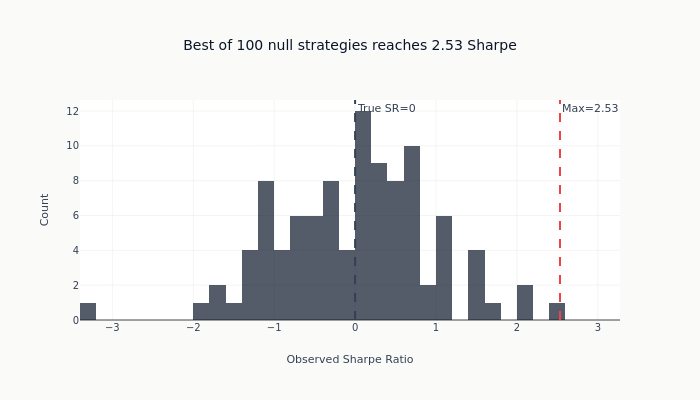

In [11]:
# Visualize the distribution
fig = go.Figure()

fig.add_trace(
    go.Histogram(
        x=results["all_sharpes"],
        nbinsx=30,
        name="Observed Sharpes",
        marker_color=COLORS["blue"],
        opacity=0.7,
    )
)

# Add markers
fig.add_vline(
    x=0,
    line_dash="dash",
    line_color=COLORS["neutral"],
    annotation_text="True SR=0",
)
fig.add_vline(
    x=results["max_sharpe"],
    line_dash="dash",
    line_color=COLORS["negative"],
    annotation_text=f"Max={results['max_sharpe']:.2f}",
)

fig.update_layout(
    title=f"Best of 100 null strategies reaches {results['max_sharpe']:.2f} Sharpe",
    xaxis_title="Observed Sharpe Ratio",
    yaxis_title="Count",
    height=400,
)
show_plot(fig)

## 2. Computing the Deflated Sharpe Ratio

Use `ml4t-diagnostic` to compute DSR with proper corrections.

In [12]:
# Generate a "selected" strategy with observed Sharpe = 1.5
n_periods = 252  # 1 year
target_sharpe = 1.5

# Create returns with target Sharpe
daily_vol = 0.01
daily_mean = (target_sharpe * daily_vol) / np.sqrt(252)
returns = np.random.normal(daily_mean, daily_vol, n_periods)

# Calculate statistics
observed_sharpe = np.mean(returns) / np.std(returns, ddof=1) * np.sqrt(252)
skewness = stats.skew(returns)
kurtosis = stats.kurtosis(returns) + 3  # Excess to raw kurtosis

print(f"Observed Sharpe: {observed_sharpe:.3f}")
print(f"Skewness: {skewness:.3f}")
print(f"Excess Kurtosis: {kurtosis - 3:.3f}")

Observed Sharpe: 1.346
Skewness: -0.019
Excess Kurtosis: -0.182


In [13]:
# Compute DSR with different numbers of trials
trials_list = [1, 5, 10, 25, 50, 100, 200, 500]
dsr_results = []

# Variance of trials (assumed constant for demonstration)
variance_trials = 0.5  # Typical variance of Sharpe across trials

for k in trials_list:
    # Compute DSR
    dsr_result = deflated_sharpe_ratio(
        observed_sharpe=observed_sharpe,
        skewness=skewness,
        kurtosis=kurtosis,
        n_samples=n_periods,
        n_trials=k,
        variance_trials=variance_trials,
        return_format="probability",
    )

    dsr_results.append({"n_trials": k, "dsr_probability": dsr_result})

dsr_df = pl.DataFrame(dsr_results)

**DSR vs number of trials** (multiple-testing haircut: same observed Sharpe,
more trials means a higher null bound and a lower DSR):

In [14]:
dsr_df

n_trials,dsr_probability
i64,f64
1,0.909877
5,0.691612
10,0.591536
25,0.4737
50,0.396471
100,0.32942
200,0.27196
500,0.209274


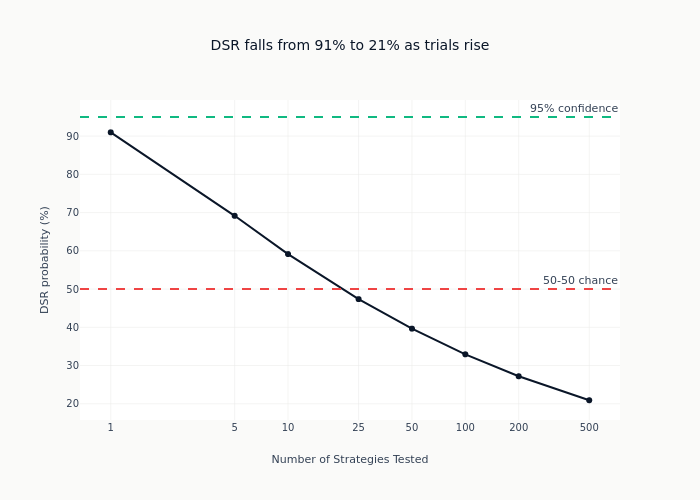

In [15]:
# Visualize DSR decay with number of trials
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=dsr_df.get_column("n_trials").to_list(),
        y=(dsr_df.get_column("dsr_probability") * 100).to_list(),
        mode="lines+markers",
        name="DSR Probability",
        line={"color": COLORS["blue"], "width": 2},
    )
)
fig.add_hline(
    y=95,
    line_dash="dash",
    line_color=COLORS["positive"],
    annotation_text="95% confidence",
)
fig.add_hline(
    y=50,
    line_dash="dash",
    line_color=COLORS["negative"],
    annotation_text="50-50 chance",
)
fig.update_layout(
    title=(
        f"DSR falls from {dsr_df['dsr_probability'][0]:.0%} to "
        f"{dsr_df['dsr_probability'][-1]:.0%} as trials rise"
    ),
    xaxis_title="Number of Strategies Tested",
    yaxis_title="DSR probability (%)",
    xaxis_type="log",
    height=500,
)
_n_trials_ticks = dsr_df.get_column("n_trials").to_list()
fig.update_xaxes(
    tickmode="array",
    tickvals=_n_trials_ticks,
    ticktext=[str(t) for t in _n_trials_ticks],
)
show_plot(fig)

## 3. Different Output Formats

The DSR function supports multiple output formats for different use cases.

In [16]:
k = 50
dsr_inputs = {
    "observed_sharpe": observed_sharpe,
    "skewness": skewness,
    "kurtosis": kurtosis,
    "n_samples": n_periods,
    "n_trials": k,
    "variance_trials": variance_trials,
}
dsr_prob = deflated_sharpe_ratio(**dsr_inputs, return_format="probability")
dsr_zscore = deflated_sharpe_ratio(**dsr_inputs, return_format="zscore")
dsr_adjusted = deflated_sharpe_ratio(**dsr_inputs, return_format="adjusted")

print("=" * 60)
print(f"DSR RESULTS (Observed SR={observed_sharpe:.3f}, K={k} trials)")
print("=" * 60)
print(f"\nProbability above the selection benchmark: {dsr_prob:.1%}")
print(f"Z-score: {dsr_zscore:.3f}")
print(f"Adjusted Sharpe: {dsr_adjusted:.3f}")

DSR RESULTS (Observed SR=1.346, K=50 trials)

Probability above the selection benchmark: 39.6%
Z-score: -0.262
Adjusted Sharpe: -0.264


## 4. Non-Normality Adjustments

Skewness and kurtosis significantly affect Sharpe ratio reliability.

In [17]:
# Analyze impact of non-normality
skewness_values = [-1.5, -0.5, 0, 0.5, 1.5]
kurtosis_values = [3, 5, 7, 10]  # Raw kurtosis (normal = 3)

results_matrix = []

for skew in skewness_values:
    for kurt in kurtosis_values:
        dsr = deflated_sharpe_ratio(
            observed_sharpe=1.5,
            skewness=skew,
            kurtosis=kurt,
            n_samples=252,
            n_trials=50,
            variance_trials=0.5,
            return_format="probability",
        )
        results_matrix.append(
            {
                "skewness": skew,
                "kurtosis": kurt,
                "excess_kurtosis": kurt - 3,
                "dsr_probability": dsr,
            }
        )

nonnorm_df = pl.DataFrame(results_matrix)

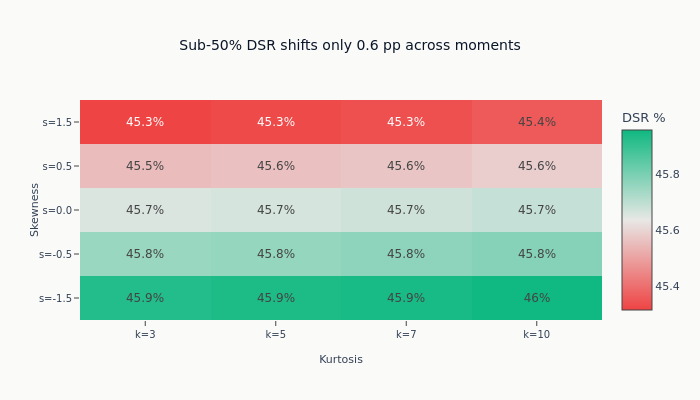

In [18]:
# Create heatmap - pivot the data
pivot = nonnorm_df.pivot(on="kurtosis", index="skewness", values="dsr_probability")
skew_col = pivot.get_column("skewness").to_list()
kurt_cols = [c for c in pivot.columns if c != "skewness"]
z_values = pivot.select(kurt_cols).to_numpy() * 100

fig = go.Figure(
    data=go.Heatmap(
        z=z_values,
        x=[f"k={k}" for k in kurt_cols],
        y=[f"s={s:.1f}" for s in skew_col],
        colorscale=ml4t_diverging(),
        colorbar={"title": "DSR %"},
        text=np.round(z_values, 1),
        texttemplate="%{text}%",
        textfont={"size": 12},
    )
)

fig.update_layout(
    title=f"Sub-50% DSR shifts only {z_values.max() - z_values.min():.1f} pp across moments",
    xaxis_title="Kurtosis",
    yaxis_title="Skewness",
    height=400,
)
show_plot(fig)

## 5. Synthetic Sweep: Selecting the Best of 30 Variants

**Scope**: this section demonstrates the DSR adjustment on a *synthetic* set of
30 strategy variants with the same known true Sharpe of 0.5. No ETF prices are
loaded and no momentum signal is computed; the input is parametric return draws
over 504 days. The point is to show how selecting the largest observed Sharpe
raises the relevant null benchmark. For the real-data ETF momentum sweep in
`case_studies/etfs/14_backtest.py` and the cohort-level DSR computation, see
the Ch16 helper `_etf_baseline.py` and `case_studies/etfs/18_strategy_analysis.py`.

In [19]:
# Generate 30 synthetic variants that share the same true Sharpe.
n_variants = 30
true_sharpe = 0.5
n_periods = 504
daily_vol = 0.015
daily_mean = true_sharpe * daily_vol / np.sqrt(252)

variant_results = []
variant_returns = np.empty((n_periods, n_variants))

for i in range(n_variants):
    candidate_returns = np.random.normal(daily_mean, daily_vol, n_periods)
    variant_returns[:, i] = candidate_returns
    obs_sharpe = candidate_returns.mean() / candidate_returns.std(ddof=1) * np.sqrt(252)
    variant_results.append(
        {
            "variant": i + 1,
            "observed_sharpe": obs_sharpe,
            "skewness": stats.skew(candidate_returns),
            "kurtosis": stats.kurtosis(candidate_returns) + 3,
        }
    )

variants_df = pl.DataFrame(variant_results)
best = variants_df.filter(pl.col("observed_sharpe") == pl.col("observed_sharpe").max()).row(
    0, named=True
)

print(f"Sampled {n_variants} synthetic strategy variants")
print(f"\nBest variant (#{int(best['variant'])}):")
print(f"  Observed Sharpe: {best['observed_sharpe']:.3f}")
print(f"  Skewness: {best['skewness']:.3f}")
print(f"  Kurtosis: {best['kurtosis']:.3f}")

Sampled 30 synthetic strategy variants

Best variant (#29):
  Observed Sharpe: 2.637
  Skewness: 0.023
  Kurtosis: 3.014


In [20]:
# Compute variance of Sharpe across variants
variance_across_variants = variants_df.get_column("observed_sharpe").var()

# Compute DSR for best variant
dsr_best = deflated_sharpe_ratio(
    observed_sharpe=best["observed_sharpe"],
    skewness=best["skewness"],
    kurtosis=best["kurtosis"],
    n_samples=n_periods,
    n_trials=n_variants,
    variance_trials=variance_across_variants,
    return_format="probability",
)

# Also compute raw PSR (without multiple testing correction)
psr_best = probabilistic_sharpe_ratio(
    observed_sr=best["observed_sharpe"],
    benchmark_sr=0.0,
    skewness=best["skewness"],
    kurtosis=best["kurtosis"],
    n_observations=n_periods,
)

print("=" * 60)
print("DSR ADJUSTMENT ON BEST-OF-30 SYNTHETIC VARIANTS")
print("=" * 60)
print(f"\nVariants sampled: {n_variants}")
print(f"Variance across variants: {variance_across_variants:.4f}")
print(f"\nBest variant Sharpe: {best['observed_sharpe']:.3f}")
print("\nWithout multiple-testing correction (PSR):")
print(f"  Probability SR > 0: {psr_best:.1%}")
print("\nWith multiple-testing correction (DSR):")
print(f"  Probability above selection benchmark: {dsr_best:.1%}")
print(f"\n{'SIGNIFICANT' if dsr_best > 0.95 else 'NOT SIGNIFICANT'} at 95% confidence")

DSR ADJUSTMENT ON BEST-OF-30 SYNTHETIC VARIANTS

Variants sampled: 30
Variance across variants: 0.8654

Best variant Sharpe: 2.637

Without multiple-testing correction (PSR):
  Probability SR > 0: 100.0%

With multiple-testing correction (DSR):
  Probability above selection benchmark: 84.0%

NOT SIGNIFICANT at 95% confidence


## 6. Comparison: DSR vs RAS

Both DSR and RAS address backtest overfitting, but from different perspectives:
- **DSR**: Multiple testing correction (how many strategies tested?)
- **RAS**: Complexity penalty (how readily the candidate return class fits random signs)

In [21]:
# Compute complexity from the same candidate return class selected above.
R_hat = rademacher_complexity(
    variant_returns,
    n_simulations=1000,
    random_state=SEED,
)

# Apply RAS adjustment (expects array input)
ras_adjusted = ras_sharpe_adjustment(
    observed_sharpe=np.array([best["observed_sharpe"]]),
    complexity=R_hat,
    n_samples=n_periods,
    n_strategies=n_variants,
    delta=0.05,
)[0]  # Get scalar result

# DSR adjusted Sharpe
dsr_adjusted_sharpe = deflated_sharpe_ratio(
    observed_sharpe=best["observed_sharpe"],
    skewness=best["skewness"],
    kurtosis=best["kurtosis"],
    n_samples=n_periods,
    n_trials=n_variants,
    variance_trials=variance_across_variants,
    return_format="adjusted",
)

print("=" * 60)
print("DSR vs RAS COMPARISON")
print("=" * 60)
print(f"\nObserved Sharpe: {best['observed_sharpe']:.3f}")
print(f"\nDSR Adjusted Sharpe: {dsr_adjusted_sharpe:.3f}")
print(f"RAS Adjusted Sharpe: {ras_adjusted:.3f}")
print(f"\nRademacher Complexity: {R_hat:.4f}")
print("\nInterpretation:")
print(f"  DSR penalizes for {n_variants} trials tested")
print(f"  RAS penalizes the candidate return class (R={R_hat:.4f})")

DSR vs RAS COMPARISON

Observed Sharpe: 2.637

DSR Adjusted Sharpe: 0.708
RAS Adjusted Sharpe: 2.103

Rademacher Complexity: 0.0014

Interpretation:
  DSR penalizes for 30 trials tested
  RAS penalizes the candidate return class (R=0.0014)


In [22]:
# Visualize adjustments across range of observed Sharpes
observed_range = np.linspace(0.5, 2.5, 20)

dsr_adjusted_list = []
ras_adjusted_list = []

for sr in observed_range:
    dsr_adj = deflated_sharpe_ratio(
        observed_sharpe=sr,
        skewness=-0.3,
        kurtosis=4.0,
        n_samples=n_periods,
        n_trials=n_variants,
        variance_trials=0.3,
        return_format="adjusted",
    )

    ras_adj = ras_sharpe_adjustment(
        observed_sharpe=np.array([sr]),
        complexity=R_hat,
        n_samples=n_periods,
        n_strategies=n_variants,
        delta=0.05,
    )[0]

    dsr_adjusted_list.append(dsr_adj)
    ras_adjusted_list.append(ras_adj)

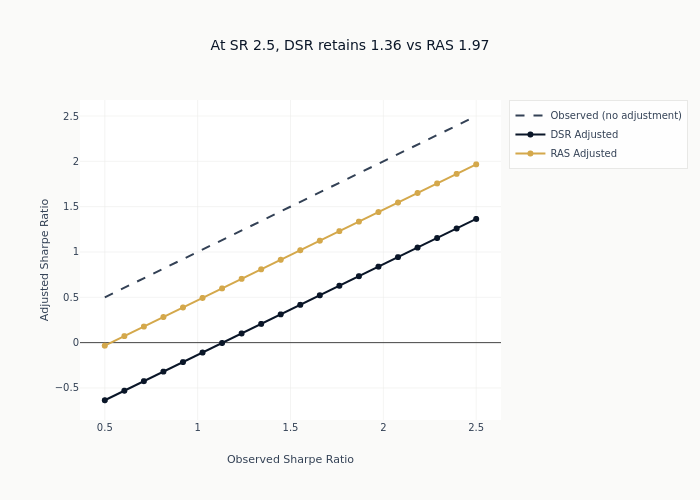

In [23]:
# Plot DSR vs RAS adjustments
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=observed_range,
        y=observed_range,
        mode="lines",
        name="Observed (no adjustment)",
        line={"dash": "dash", "color": COLORS["neutral"]},
    )
)
fig.add_trace(
    go.Scatter(
        x=observed_range,
        y=dsr_adjusted_list,
        mode="lines+markers",
        name="DSR Adjusted",
        line={"color": COLORS["blue"]},
    )
)
fig.add_trace(
    go.Scatter(
        x=observed_range,
        y=ras_adjusted_list,
        mode="lines+markers",
        name="RAS Adjusted",
        line={"color": COLORS["amber"]},
    )
)

fig.update_layout(
    title=(
        f"At SR {observed_range[-1]:.1f}, DSR retains {dsr_adjusted_list[-1]:.2f} "
        f"vs RAS {ras_adjusted_list[-1]:.2f}"
    ),
    xaxis_title="Observed Sharpe Ratio",
    yaxis_title="Adjusted Sharpe Ratio",
    height=500,
)
show_plot(fig)

## 7. Practical Guidelines

### When to Use DSR vs RAS

| Situation | Recommended Method |
|-----------|--------------------|
| Many strategy variants tested | DSR |
| Complex ML model | RAS |
| Parameter optimization | DSR |
| Feature selection | RAS |
| Both apply | Use both, report more conservative |

### Minimum Sharpe Thresholds (After Adjustment)

The required observed Sharpe is not a universal lookup value. It depends on
sample length, trial dispersion, skewness, and kurtosis. The calculation below
holds those assumptions fixed and solves the threshold for each trial count.

In [24]:
# Compute minimum Sharpe for significance at different trial counts
trial_counts = [5, 10, 25, 50, 100, 200, 500]
min_sharpes = []

for k in trial_counts:
    # Binary search for minimum Sharpe that gives DSR > 0.95
    low, high = 0.5, 4.0

    while high - low > 0.01:
        mid = (low + high) / 2
        dsr = deflated_sharpe_ratio(
            observed_sharpe=mid,
            skewness=-0.3,
            kurtosis=4.0,
            n_samples=504,  # 2 years
            n_trials=k,
            variance_trials=0.3,
            return_format="probability",
        )

        if dsr < 0.95:
            low = mid
        else:
            high = mid

    min_sharpes.append({"n_trials": k, "min_sharpe_95": (low + high) / 2})

min_sharpe_df = pl.DataFrame(min_sharpes)

**Minimum observed Sharpe for 95% DSR confidence** at each number of trials:

In [25]:
min_sharpe_df

n_trials,min_sharpe_95
i64,f64
5,1.843262
10,2.055176
25,2.294434
50,2.444824
100,2.588379
200,2.718262
500,2.882324


## 8. Probability of Backtest Overfitting (PBO)

PBO complements DSR with a *selection-process* question. After partitioning
observations into an even number of blocks, combinatorial symmetric
cross-validation (CSCV) assigns half the blocks to IS and the complement to
OOS. How often does the IS winner rank in the bottom half OOS?

Each row of the input matrices must represent one complementary CSCV split,
and each cell must be computed from the corresponding strategy return series.
Independent random IS/OOS score matrices do not implement this mechanism.

We construct two diagnostic scenarios using real simulated return series:

1. **All-noise universe.** Every candidate has true SR = 0. Selection on the
   in-sample maximum is selection on noise.
2. **Mixed universe.** A handful of candidates have a real edge; the rest are
   noise. Stable candidates can retain an advantage in both IS and OOS.

In [26]:
from ml4t.diagnostic.evaluation.stats import compute_pbo

PBO_OBSERVATIONS = 4800
N_BLOCKS = 10
N_STRATEGIES = 20
PBO_TRUE_SR_SIGNAL = 1.5
DSR_PASS_THRESHOLD = 0.95
PBO_REJECT_THRESHOLD = 0.25

Simulate candidate return histories for the DSR and PBO comparison.

In [27]:
def simulate_strategy_returns(
    true_sr_by_strategy: np.ndarray,
    n_observations: int,
    daily_vol: float = 0.01,
    seed: int = 0,
) -> np.ndarray:
    """Simulate one return history for every candidate strategy."""
    rng = np.random.default_rng(seed)
    daily_means = true_sr_by_strategy * daily_vol / np.sqrt(252)
    return rng.normal(
        loc=daily_means,
        scale=daily_vol,
        size=(n_observations, len(true_sr_by_strategy)),
    )

In [28]:
def _sharpe_from_moments(count: int, sums: np.ndarray, sums_sq: np.ndarray) -> np.ndarray:
    """Compute annualized sample Sharpes from sufficient statistics."""
    means = sums / count
    variances = np.maximum((sums_sq - sums**2 / count) / (count - 1), 1e-12)
    return means / np.sqrt(variances) * np.sqrt(252)

Construct complementary in-sample and out-of-sample CSCV Sharpe matrices.

In [29]:
def cscv_sharpe_matrices(
    strategy_returns: np.ndarray,
    n_blocks: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Build complementary IS/OOS Sharpe rows for every CSCV combination."""
    if n_blocks < 2 or n_blocks % 2:
        raise ValueError("n_blocks must be an even integer of at least 2")
    blocks = np.array_split(strategy_returns, n_blocks, axis=0)
    counts = np.array([len(block) for block in blocks])
    sums = np.stack([block.sum(axis=0) for block in blocks])
    sums_sq = np.stack([(block**2).sum(axis=0) for block in blocks])
    total_count, total_sums = counts.sum(), sums.sum(axis=0)
    total_sums_sq = sums_sq.sum(axis=0)
    split_indices = list(combinations(range(n_blocks), n_blocks // 2))
    is_sharpes = np.empty((len(split_indices), strategy_returns.shape[1]))
    oos_sharpes = np.empty_like(is_sharpes)
    for row, selected in enumerate(split_indices):
        selected = np.asarray(selected)
        is_count = int(counts[selected].sum())
        is_sums = sums[selected].sum(axis=0)
        is_sums_sq = sums_sq[selected].sum(axis=0)
        is_sharpes[row] = _sharpe_from_moments(is_count, is_sums, is_sums_sq)
        oos_sharpes[row] = _sharpe_from_moments(
            total_count - is_count, total_sums - is_sums, total_sums_sq - is_sums_sq
        )
    return is_sharpes, oos_sharpes

### Scenario 1 - All Strategies Are Noise (true SR = 0)

Selection on the in-sample maximum is selection on noise. The output reports
the resulting rank-instability frequency for this simulated panel.

In [30]:
true_sr_noise = np.zeros(N_STRATEGIES)
noise_returns = simulate_strategy_returns(
    true_sr_noise,
    n_observations=PBO_OBSERVATIONS,
    seed=42,
)
is_noise, oos_noise = cscv_sharpe_matrices(noise_returns, N_BLOCKS)
pbo_noise = compute_pbo(is_performance=is_noise, oos_performance=oos_noise)
pbo_noise_dict = pbo_noise.to_dict() if hasattr(pbo_noise, "to_dict") else pbo_noise

print(
    f"All-noise PBO: {pbo_noise_dict['pbo']:.1%} "
    "(selection on noise has no persistent OOS advantage)"
)

All-noise PBO: 70.2% (selection on noise has no persistent OOS advantage)


### Scenario 2 - Three Strategies Carry True Edge

Hidden ground truth: strategies 0, 7, 14 have a stable positive expected
return; the rest are noise. The output measures the resulting PBO.

In [31]:
true_sr_mixed = np.zeros(N_STRATEGIES)
true_sr_mixed[[0, 7, 14]] = PBO_TRUE_SR_SIGNAL
mixed_returns = simulate_strategy_returns(
    true_sr_mixed,
    n_observations=PBO_OBSERVATIONS,
    seed=42,
)
is_mixed, oos_mixed = cscv_sharpe_matrices(mixed_returns, N_BLOCKS)
pbo_mixed = compute_pbo(is_performance=is_mixed, oos_performance=oos_mixed)
pbo_mixed_dict = pbo_mixed.to_dict() if hasattr(pbo_mixed, "to_dict") else pbo_mixed

print(
    f"Mixed-edge PBO: {pbo_mixed_dict['pbo']:.1%} "
    "(stable edge can persist across complementary samples)"
)

Mixed-edge PBO: 0.0% (stable edge can persist across complementary samples)


### Scenario Comparison

The table below contrasts the two scenarios and shows whether adding stable
positive-mean candidates changes PBO for this draw.

In [32]:
# Headline scenario for the rest of the section / figure.
is_performance = is_mixed
oos_performance = oos_mixed
pbo_result = pbo_mixed
pbo_result_dict = pbo_mixed_dict
pbo_value = pbo_result_dict["pbo"]

pl.DataFrame(
    {
        "scenario": [
            "All noise (SR=0 for all)",
            f"Mixed (3 strategies with SR={PBO_TRUE_SR_SIGNAL:g})",
        ],
        "pbo": [pbo_noise_dict["pbo"], pbo_mixed_dict["pbo"]],
        "n_combinations": [
            pbo_noise_dict.get("n_combinations", 0),
            pbo_mixed_dict.get("n_combinations", 0),
        ],
        "degradation_mean": [
            pbo_noise_dict.get("degradation_mean", pbo_noise_dict.get("degradation")),
            pbo_mixed_dict.get("degradation_mean", pbo_mixed_dict.get("degradation")),
        ],
    }
)

scenario,pbo,n_combinations,degradation_mean
str,f64,i64,f64
"""All noise (SR=0 for all)""",0.702381,252,0.68256
"""Mixed (3 strategies with SR=1.…",0.0,252,0.318742


### 8.1 PBO Parameter Sensitivity

The number of blocks changes the number of complementary CSCV splits. We
repartition the same mixed-edge return panel so the data and IS/OOS sample
sizes remain fixed.

In [33]:
block_counts = [4, 6, 8, 10, 12, 16]
pbo_by_blocks = []

for n_blocks in block_counts:
    is_perf, oos_perf = cscv_sharpe_matrices(mixed_returns, n_blocks)
    pbo_res = compute_pbo(is_performance=is_perf, oos_performance=oos_perf)
    pbo_res_dict = pbo_res.to_dict() if hasattr(pbo_res, "to_dict") else pbo_res
    pbo_by_blocks.append(
        {
            "n_blocks": n_blocks,
            "pbo": pbo_res_dict["pbo"],
            "n_combinations": pbo_res_dict.get("n_combinations", 0),
        }
    )

pbo_blocks_df = pl.DataFrame(pbo_by_blocks)

**PBO vs number of CSCV blocks** for the same simulated return panel:

In [34]:
pbo_blocks_df

n_blocks,pbo,n_combinations
i64,f64,i64
4,0.0,6
6,0.0,20
8,0.0,70
10,0.0,252
12,0.0,924
16,0.0,12870


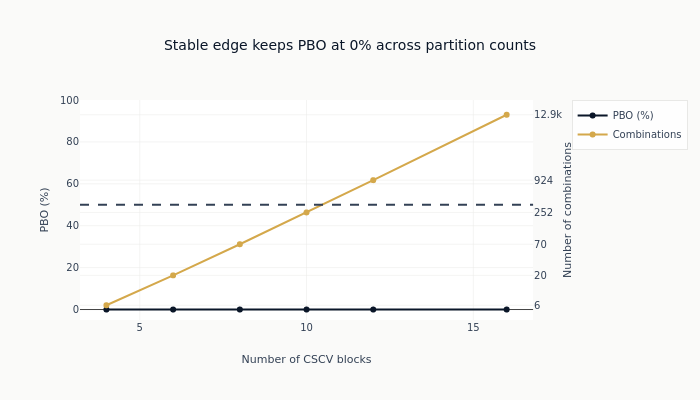

In [35]:
# Visualize PBO sensitivity to the CSCV partition count.
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(
    go.Scatter(
        x=pbo_blocks_df["n_blocks"].to_list(),
        y=(pbo_blocks_df["pbo"] * 100).to_list(),
        name="PBO (%)",
        mode="lines+markers",
        line={"color": COLORS["blue"]},
    ),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(
        x=pbo_blocks_df["n_blocks"].to_list(),
        y=pbo_blocks_df["n_combinations"].to_list(),
        name="Combinations",
        mode="lines+markers",
        line={"color": COLORS["amber"]},
    ),
    secondary_y=True,
)

fig.update_layout(
    title="Stable edge keeps PBO at 0% across partition counts",
    xaxis_title="Number of CSCV blocks",
    height=400,
)
fig.add_hline(y=50, line_dash="dash", line_color=COLORS["neutral"], secondary_y=False)
fig.update_yaxes(title_text="PBO (%)", range=[-5, 100], secondary_y=False)
fig.update_yaxes(
    title_text="Number of combinations",
    type="log",
    tickmode="array",
    tickvals=pbo_blocks_df["n_combinations"].to_list(),
    ticktext=["6", "20", "70", "252", "924", "12.9k"],
    secondary_y=True,
)
show_plot(fig)

### 8.2 Case Study: DSR and PBO Answer Different Questions

DSR evaluates the selected Sharpe against a multiple-testing benchmark. PBO
evaluates whether IS selection is stable across complementary samples. The
return panel below gives each candidate a different block-specific edge with
zero average across blocks, creating temporal instability without inventing
independent IS/OOS score matrices. The computed diagnostics determine the
verdict; the example does not force either method to pass or fail.

In [36]:
def simulate_regime_sensitive_returns(
    n_observations: int,
    n_strategies: int,
    n_blocks: int,
    seed: int,
    block_sharpe_scale: float = 3.0,
    daily_vol: float = 0.01,
) -> np.ndarray:
    """Simulate candidates whose expected returns vary across time blocks."""
    rng = np.random.default_rng(seed)
    block_sharpes = rng.normal(0, block_sharpe_scale, (n_blocks, n_strategies))
    block_sharpes -= block_sharpes.mean(axis=0, keepdims=True)
    result = np.empty((n_observations, n_strategies))
    for indices, block_sr in zip(
        np.array_split(np.arange(n_observations), n_blocks), block_sharpes
    ):
        daily_means = block_sr * daily_vol / np.sqrt(252)
        result[indices] = rng.normal(daily_means, daily_vol, (len(indices), n_strategies))
    return result

In [37]:
true_n_trials = 200
reported_n_trials = 10
overfit_returns = simulate_regime_sensitive_returns(
    n_observations=PBO_OBSERVATIONS,
    n_strategies=true_n_trials,
    n_blocks=N_BLOCKS,
    seed=123,
)
is_perf_overfit, oos_perf_overfit = cscv_sharpe_matrices(overfit_returns, N_BLOCKS)
best_idx = int(np.argmax(is_perf_overfit[0]))
best_is_sharpe = float(is_perf_overfit[0, best_idx])
best_oos_sharpe = float(oos_perf_overfit[0, best_idx])
first_blocks = np.array_split(overfit_returns, N_BLOCKS, axis=0)[: N_BLOCKS // 2]
first_is_returns = np.concatenate(first_blocks)[:, best_idx]
is_skewness = float(stats.skew(first_is_returns))
is_kurtosis = float(stats.kurtosis(first_is_returns) + 3)
is_sharpe_variance = float(np.var(is_perf_overfit[0], ddof=1))

In [38]:
# Compute DSR with under-reported and true trial counts, compare to PBO
dsr_underreported = deflated_sharpe_ratio(
    observed_sharpe=best_is_sharpe,
    skewness=is_skewness,
    kurtosis=is_kurtosis,
    n_samples=len(first_is_returns),
    n_trials=reported_n_trials,
    variance_trials=is_sharpe_variance,
    return_format="probability",
)

dsr_true = deflated_sharpe_ratio(
    observed_sharpe=best_is_sharpe,
    skewness=is_skewness,
    kurtosis=is_kurtosis,
    n_samples=len(first_is_returns),
    n_trials=true_n_trials,
    variance_trials=is_sharpe_variance,
    return_format="probability",
)

pbo_overfit = compute_pbo(
    is_performance=is_perf_overfit,
    oos_performance=oos_perf_overfit,
)
pbo_overfit_dict = pbo_overfit.to_dict() if hasattr(pbo_overfit, "to_dict") else pbo_overfit

In [39]:
print("\n" + "=" * 70)
print("CASE STUDY: TRIAL CORRECTION AND TEMPORAL STABILITY")
print("=" * 70)
print(f"\nTrue trials tested: {true_n_trials}")
print(f"Reported trials: {reported_n_trials}")
print(f"\nBest strategy IS Sharpe: {best_is_sharpe:.2f}")
print(f"Best strategy OOS Sharpe: {best_oos_sharpe:.2f}")
print(f"Performance degradation: {(best_is_sharpe - best_oos_sharpe):.2f}")

_ur_verdict = "passes" if dsr_underreported >= DSR_PASS_THRESHOLD else "fails"
_true_verdict = "passes" if dsr_true >= DSR_PASS_THRESHOLD else "fails"
_pbo_verdict = (
    "flags instability" if pbo_overfit_dict["pbo"] > PBO_REJECT_THRESHOLD else "does not flag"
)

print("\n--- DETECTION RESULTS ---")
print(f"DSR (under-reported trials={reported_n_trials}): {dsr_underreported:.1%}, {_ur_verdict}")
print(f"DSR (true trial count={true_n_trials}): {dsr_true:.1%}, {_true_verdict}")
print(f"PBO (all CSCV splits): {pbo_overfit_dict['pbo']:.1%}, {_pbo_verdict}")
print("\nDSR tests the selected split against its trial benchmark.")
print("PBO tests whether selection persists across complementary time blocks.")


CASE STUDY: TRIAL CORRECTION AND TEMPORAL STABILITY

True trials tested: 200
Reported trials: 10

Best strategy IS Sharpe: 2.37
Best strategy OOS Sharpe: -2.58
Performance degradation: 4.95

--- DETECTION RESULTS ---
DSR (under-reported trials=10): 99.4%, passes
DSR (true trial count=200): 12.5%, fails
PBO (all CSCV splits): 100.0%, flags instability

DSR tests the selected split against its trial benchmark.
PBO tests whether selection persists across complementary time blocks.


### 8.3 DSR vs PBO: When to Use Each

| Method | Best For | Measures |
|--------|----------|----------|
| **DSR** | Known trial count and dispersion | Evidence above a selection benchmark |
| **PBO** | CSCV strategy selection | Frequency IS winner ranks below median OOS |
| **RAS** | Candidate performance matrix | Complexity-based lower performance bound |

**Decision Framework**:

1. Use DSR when the trial count and cross-trial dispersion are known.
2. Use PBO when complementary CSCV performance is available.
3. Use RAS when the candidate return or prediction class is available.
4. Set decision thresholds before looking at the diagnostic results.
5. Treat these diagnostics as complementary evidence, not deployment rules.

**Recommendation**: Use multiple methods. If any raises red flags, investigate further.

## 9. Key Takeaways

### Critical Insights

1. **Selection bias is measurable**: The best null Sharpe rises with the number of trials
2. **Non-normality is conditional**: Skew and kurtosis change the DSR denominator.
   When the observed Sharpe is below its benchmark, a larger denominator moves the
   negative z-score toward zero and can raise the probability slightly; above the
   benchmark, the direction reverses.
3. **DSR provides a calibrated statistic**: Its benchmark includes the selection process
4. **PBO uses CSCV**: Every IS block assignment is paired with its OOS complement
5. **Combine methods**: DSR, PBO, and RAS for comprehensive overfitting detection

### Practical Rules

1. **Always track trials**: Record every strategy variant tested
2. **Report DSR alongside raw Sharpe**: Disclose the full trial count
3. **Use realistic parameters**: Include non-normality in calculations
4. **Pre-register thresholds**: Choose decision criteria before inspecting results

### Integration Checklist

- [ ] Count all strategy variants tested
- [ ] Calculate Sharpe variance across variants
- [ ] Measure return skewness and kurtosis
- [ ] Compute DSR with all parameters
- [ ] Compute PBO with complementary CSCV splits
- [ ] Compare DSR, PBO, and RAS results
- [ ] Apply pre-registered decision criteria and investigate disagreements

In [40]:
# Summary
print("=" * 80)
print("OVERFITTING DETECTION SUMMARY")
print("=" * 80)

print("\n1. SELECTION BIAS DEMONSTRATION:")
print(f"   - Tested 100 null strategies, best had SR = {results['max_sharpe']:.2f}")
print("   - Every candidate was generated with zero expected return")

print("\n2. DSR DECAY WITH TRIALS:")
print(f"   - 1 trial: DSR = {dsr_df.row(0, named=True)['dsr_probability']:.1%}")
print(f"   - 100 trials: DSR = {dsr_df.row(5, named=True)['dsr_probability']:.1%}")
print(f"   - 500 trials: DSR = {dsr_df.row(7, named=True)['dsr_probability']:.1%}")

print("\n3. CASE STUDY RESULT:")
print(f"   - Best synthetic variant: SR = {best['observed_sharpe']:.2f}")
print(f"   - Without correction (PSR): {psr_best:.1%}")
print(f"   - With DSR correction: {dsr_best:.1%}")

print("\n4. DSR vs RAS:")
print(f"   - DSR adjusted Sharpe: {dsr_adjusted_sharpe:.3f}")
print(f"   - RAS adjusted Sharpe: {ras_adjusted:.3f}")

print("\n5. PBO ANALYSIS:")
print(f"   - Probability of Backtest Overfitting: {pbo_value:.1%}")
print("   - Computed from all complementary CSCV splits")

print("\n" + "=" * 80)

OVERFITTING DETECTION SUMMARY

1. SELECTION BIAS DEMONSTRATION:
   - Tested 100 null strategies, best had SR = 2.53
   - Every candidate was generated with zero expected return

2. DSR DECAY WITH TRIALS:
   - 1 trial: DSR = 91.0%
   - 100 trials: DSR = 32.9%
   - 500 trials: DSR = 20.9%

3. CASE STUDY RESULT:
   - Best synthetic variant: SR = 2.64
   - Without correction (PSR): 100.0%
   - With DSR correction: 84.0%

4. DSR vs RAS:
   - DSR adjusted Sharpe: 0.708
   - RAS adjusted Sharpe: 2.103

5. PBO ANALYSIS:
   - Probability of Backtest Overfitting: 0.0%
   - Computed from all complementary CSCV splits

